In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from src.preprocessing import fit_preprocessing, transform_preprocessor
from src.models import compare_models, predict_and_score
from src.utils import roc_graph

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

C:\Users\qkrth\miniconda3\envs\aistudy_env\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 코드 테스트

In [2]:
# 데이터 호출
df = pd.read_csv("../01_data/processed/model_df.csv")

In [3]:
# X/y split
X = df.drop('churned', axis=1)
y = df['churned']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# tr/val split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

In [4]:
# 데이터 전처리 함수 호출
X_tr_prep, encoders, scaler = fit_preprocessing(X_tr)
X_val_prep = transform_preprocessor(X_val, encoders, scaler)
X_test_prep = transform_preprocessor(X_test, encoders, scaler)

In [5]:
models = compare_models(X_tr, X_tr_prep, X_val, X_val_prep, y_tr, y_val)

In [6]:
train_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        train_scores[model.__class__.__name__] = predict_and_score(model, X_tr, y_tr)
        continue

    train_scores[model.__class__.__name__] = predict_and_score(model, X_tr_prep, y_tr)


CatBoostClassifier Results
Accuracy : 0.8656
F1 Score : 0.8670
ROC AUC  : 0.9495

XGBClassifier Results
Accuracy : 0.8821
F1 Score : 0.8838
ROC AUC  : 0.9577

LGBMClassifier Results
Accuracy : 0.8749
F1 Score : 0.8773
ROC AUC  : 0.9538

RandomForestClassifier Results
Accuracy : 0.8113
F1 Score : 0.8149
ROC AUC  : 0.9013


In [7]:
val_scores = {}

for model in models:
    name = model.__class__.__name__

    if name == 'CatBoostClassifier':
        val_scores[name] = predict_and_score(model, X_val, y_val)
        continue

    val_scores[name] = predict_and_score(model, X_val_prep, y_val)


CatBoostClassifier Results
Accuracy : 0.8377
F1 Score : 0.8393
ROC AUC  : 0.9363

XGBClassifier Results
Accuracy : 0.8394
F1 Score : 0.8424
ROC AUC  : 0.9363

LGBMClassifier Results
Accuracy : 0.8412
F1 Score : 0.8446
ROC AUC  : 0.9372

RandomForestClassifier Results
Accuracy : 0.8045
F1 Score : 0.8083
ROC AUC  : 0.8949


In [8]:
test_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        test_scores[model.__class__.__name__] = predict_and_score(model, X_test, y_test)
        continue

    test_scores[model.__class__.__name__] = predict_and_score(model, X_test_prep, y_test)


CatBoostClassifier Results
Accuracy : 0.8460
F1 Score : 0.8478
ROC AUC  : 0.9415

XGBClassifier Results
Accuracy : 0.8493
F1 Score : 0.8519
ROC AUC  : 0.9416

LGBMClassifier Results
Accuracy : 0.8490
F1 Score : 0.8519
ROC AUC  : 0.9420

RandomForestClassifier Results
Accuracy : 0.8120
F1 Score : 0.8161
ROC AUC  : 0.9004


In [9]:
train_scores_df = pd.DataFrame(train_scores).T[['accuracy','f1','roc_auc']]
train_scores_df

,accuracy,f1,roc_auc
CatBoostClassifier,0.865578,0.866982,0.94953
XGBClassifier,0.882089,0.883809,0.957682
LGBMClassifier,0.874944,0.877261,0.953789
RandomForestClassifier,0.811289,0.814945,0.901312


In [10]:
val_scores_df = pd.DataFrame(val_scores).T[['accuracy', 'f1', 'roc_auc']]
val_scores_df

,accuracy,f1,roc_auc
CatBoostClassifier,0.8377,0.839291,0.936262
XGBClassifier,0.8394,0.842425,0.936306
LGBMClassifier,0.8412,0.844618,0.937171
RandomForestClassifier,0.8045,0.808277,0.894896


In [11]:
test_scores_df = pd.DataFrame(test_scores).T[['accuracy','f1','roc_auc']]
test_scores_df

,accuracy,f1,roc_auc
CatBoostClassifier,0.84596,0.847817,0.941541
XGBClassifier,0.84932,0.851862,0.941634
LGBMClassifier,0.849,0.85185,0.941974
RandomForestClassifier,0.81204,0.816079,0.900376


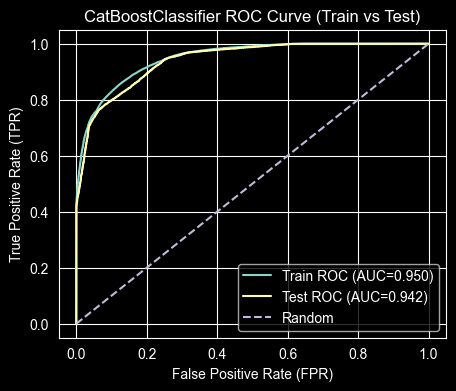

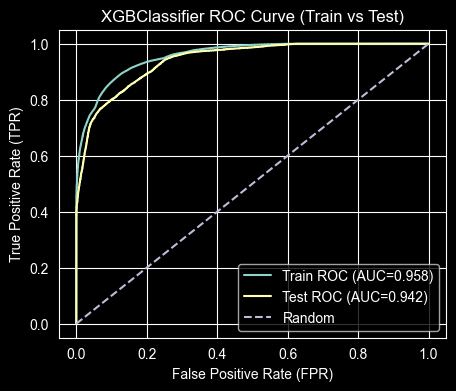

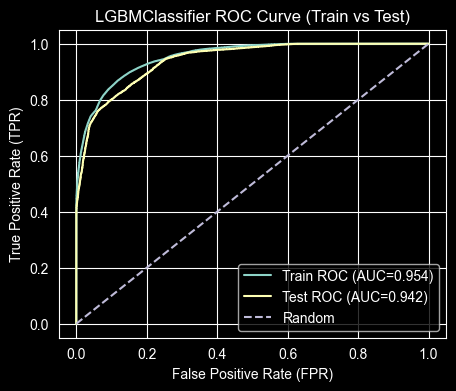

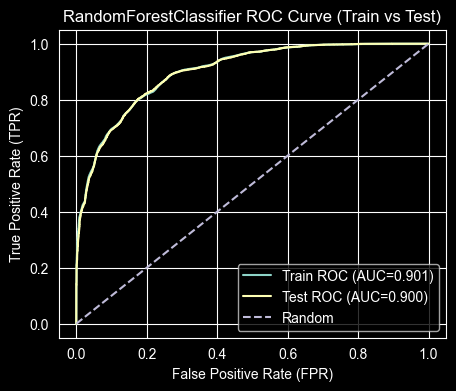

In [12]:
for model in models:

    name = model.__class__.__name__
    y_train_pred = train_scores[name]['y_proba']
    y_test_pred = test_scores[name]['y_proba']

    roc_graph(name, y_tr, y_train_pred, y_test, y_test_pred)

In [13]:
# 탐색할 파라미터 후보 리스트 정의
n_estimators_list = [100, 200, 300]
learning_rate_list = [0.01, 0.05, 0.1]
max_depth_list = [3, 5, 7]
subsample_list = [0.8, 1.0]
colsample_bytree_list = [0.8, 1.0]

In [14]:
# HyperOpt 검색 공간 설정
search_space = {
    'n_estimators': hp.choice('n_estimators', n_estimators_list),
    'learning_rate': hp.choice('learning_rate', learning_rate_list),
    'max_depth': hp.choice('max_depth', max_depth_list),
    'subsample': hp.choice('subsample', subsample_list),
    'colsample_bytree': hp.choice('colsample_bytree', colsample_bytree_list)
}

In [15]:
# 목적함수 정의
def objective(params):
    model = XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1,
        **params
    )
    # 학습 데이터(X_tr_prep)로 학습
    model.fit(X_tr_prep, y_tr)
    # 검증 데이터(X_val_prep)로 성능 확인
    y_val_pred = model.predict(X_val_prep)
    score = f1_score(y_val, y_val_pred, average='macro')
    return {'loss': -score, 'status': STATUS_OK}

In [16]:
# 최적화 실행
trials = Trials()
best_idx = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    trials=trials,
    max_evals=50,  # 50번의 똑똑한 시도
    rstate=np.random.default_rng(seed=42)
)

100%|██████████| 50/50 [02:28<00:00,  2.96s/trial, best loss: -0.8444446686683456]


In [17]:
# 찾은 인덱스를 실제 파라미터 값으로 변환
best_params = {
    'n_estimators': n_estimators_list[best_idx['n_estimators']],
    'learning_rate': learning_rate_list[best_idx['learning_rate']],
    'max_depth': max_depth_list[best_idx['max_depth']],
    'subsample': subsample_list[best_idx['subsample']],
    'colsample_bytree': colsample_bytree_list[best_idx['colsample_bytree']]
}

In [18]:
# 최적의 파라미터로 최종 모델 학습
final_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    **best_params
)
final_xgb.fit(X_tr_prep, y_tr)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [20]:
# 최종 테스트 데이터(X_test_prep)로 결과 도출
y_test_pred = final_xgb.predict(X_test_prep)


HyperOpt가 찾은 최적 파라미터: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 1.0, 'colsample_bytree': 1.0}

[최종 분류 보고서]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84     12165
           1       0.85      0.85      0.85     12835

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



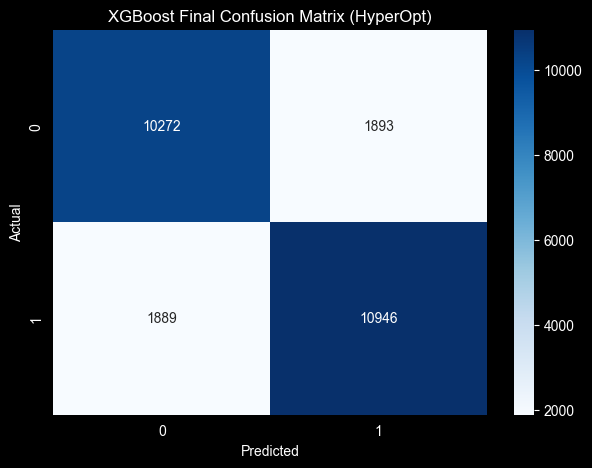

최종 Accuracy: 0.8487
최종 F1-Score: 0.8486


In [21]:
# 결과 출력
print("\n" + "="*50)
print(f"HyperOpt가 찾은 최적 파라미터: {best_params}")
print("="*50)

print("\n[최종 분류 보고서]")
print(classification_report(y_test, y_test_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Final Confusion Matrix (HyperOpt)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"최종 Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"최종 F1-Score: {f1_score(y_test, y_test_pred, average='macro'):.4f}")